In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB,BernoulliNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

In [22]:
train_data=fetch_20newsgroups(
    subset="train",
    remove=("headers","footers","quotes")
) 
test_data=fetch_20newsgroups(
    subset="test",
    remove=("headers","footers","quotes")
)

X_train_text=train_data.data
y_train=train_data.target

X_test_text=test_data.data
y_test=test_data.target

class_names=train_data.target_names

print("Training documents:",len(X_train_text))
print("Testing documents:",len(X_test_text))
print("Number of classes:",len(class_names))


Training documents: 11314
Testing documents: 7532
Number of classes: 20


In [23]:
vectorizer=CountVectorizer(
    stop_words="english",#remove common english words
    min_df=2 #keep only words appearing in at least 2 documents
)
X_train=vectorizer.fit_transform(X_train_text)
X_test=vectorizer.transform(X_test_text)

print("Training feature matrix:",X_train.shape)
print("Testing feature matrix:",X_test.shape)

Training feature matrix: (11314, 39115)
Testing feature matrix: (7532, 39115)


In [24]:
mnb=MultinomialNB()
mnb.fit(
    X_train,
    y_train
)

y_pred_mnb=mnb.predict(X_test)


binary_vectorizer=CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)
X_train_binary =binary_vectorizer.fit_transform(
    X_train_text
)
X_test_binary=binary_vectorizer.transform(
    X_test_text
)

bnb=BernoulliNB()
bnb.fit(
    X_train_binary,
    y_train
)
y_pred_bnb=bnb.predict(
    X_test_binary
)

In [25]:
mnb_accuracy = accuracy_score(y_test, y_pred_mnb)
mnb_precision = precision_score(y_test, y_pred_mnb, average='weighted')
mnb_recall = recall_score(y_test, y_pred_mnb, average='weighted')
mnb_f1 = f1_score(y_test, y_pred_mnb, average='weighted')


bnb_accuracy = accuracy_score(y_test, y_pred_bnb)
bnb_precision = precision_score(y_test, y_pred_bnb, average='weighted')
bnb_recall = recall_score(y_test, y_pred_bnb, average='weighted')
bnb_f1 = f1_score(y_test, y_pred_bnb, average='weighted')


results = pd.DataFrame({
    'Model': ['MultinomialNB', 'BernoulliNB'],
    'Accuracy': [mnb_accuracy, bnb_accuracy],
    'Precision': [mnb_precision, bnb_precision],
    'Recall': [mnb_recall, bnb_recall],
    'F1 Score': [mnb_f1, bnb_f1]
})

print(results)

           Model  Accuracy  Precision    Recall  F1 Score
0  MultinomialNB  0.651089   0.642532  0.651089  0.629644
1    BernoulliNB  0.485130   0.627034  0.485130  0.480839


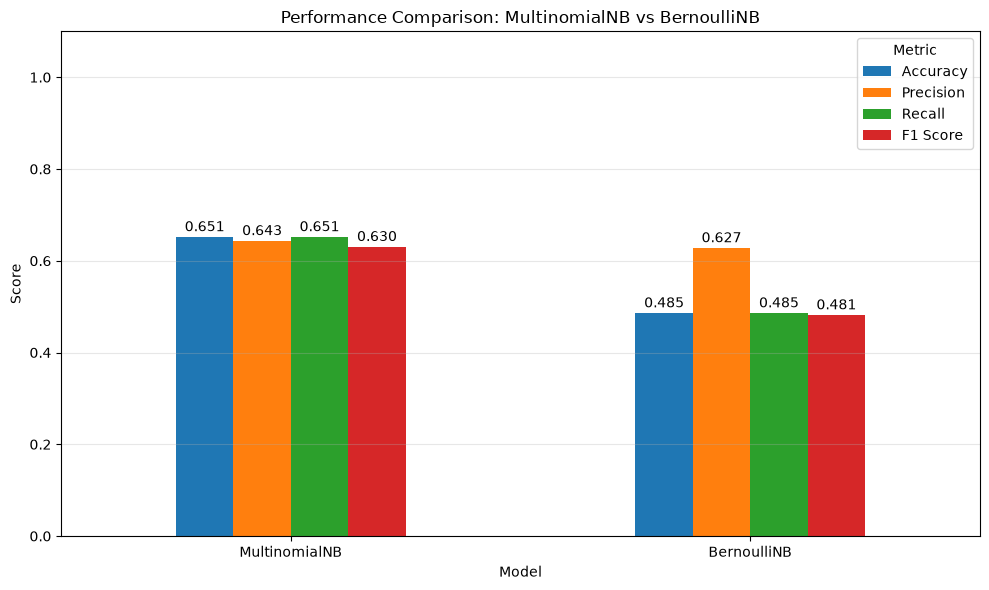

In [40]:
ax = results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6),
)

plt.title("Performance Comparison: MultinomialNB vs BernoulliNB")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.1)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=2)

plt.tight_layout()
plt.show()